

`Práctica Nº6 - Aprendizaje Profundo`



#**CLASIFICACIÓN EN DATOS ESTRUCTURADOS MEDIANTE EMBEDDINGS**

##*DataSet: Heart Disease – UCI*

#### 00. Librerias

In [ ]:
!pip install -q fastai scikit-learn pandas matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
from fastai.tabular.all import *

In [ ]:
import random
random.seed(42)
np.random.seed(42)

### 01. DataSet

In [ ]:
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

df = pd.read_csv(url, header=None, names=columns)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df = df.replace('?', np.nan)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [ ]:
df['target'] = (df['target'] > 0).astype(int)

In [ ]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    df[col] = df[col].astype('category')

print("\nInformación del dataset:")
print(df.info())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    float64 
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    float64 
 4   chol      303 non-null    float64 
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    float64 
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        299 non-null    category
 12  thal      301 non-null    category
 13  target    303 non-null    int64   
dtypes: category(8), float64(5), int64(1)
memory usage: 17.8 KB
None


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### 02. Train & Test

In [ ]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Tamaño train:", df_train.shape)
print("Tamaño test:", df_test.shape)

Tamaño train: (242, 14)
Tamaño test: (61, 14)


In [ ]:
dep_var = 'target'

procs = [Categorify, FillMissing, Normalize]

cat_names = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cont_names = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print("Variables categóricas:", cat_names)
print("Variables continuas:", cont_names)

Variables categóricas: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Variables continuas: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


### 03. DataLoader

In [ ]:
valid_idx = random.sample(range(0, len(df_train)), int(len(df_train) * 0.2))

In [ ]:
dls_train = TabularDataLoaders.from_df(
    df_train,
    path='.',
    procs=procs,
    cat_names=cat_names,
    cont_names=cont_names,
    y_names=dep_var,
    valid_idx=valid_idx,
    bs=32
)

In [ ]:
dls_train.show_batch()

,sex,cp,fbs,restecg,exang,slope,ca,thal,age,trestbps,chol,thalach,oldpeak,target
0,1.0,4.0,0.0,2.0,1.0,2.0,0.0,7.0,40.000000,110.000001,167.000002,114.000001,2.000000e+00,1.0
1,0.0,4.0,0.0,0.0,0.0,1.0,0.0,3.0,49.000000,130.000000,269.000000,163.000000,-2.575833e-08,0.0
2,0.0,3.0,0.0,0.0,0.0,2.0,0.0,3.0,42.000000,120.000000,209.000000,173.000001,-2.575833e-08,0.0
3,1.0,2.0,0.0,0.0,1.0,1.0,0.0,3.0,59.000000,140.000000,221.000000,164.000000,-2.575833e-08,0.0
4,1.0,4.0,0.0,2.0,1.0,2.0,2.0,3.0,66.999999,100.000000,298.999999,124.999999,9.000000e-01,1.0
5,1.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,52.000000,120.000000,324.999998,171.999999,2.000000e-01,0.0
6,1.0,2.0,0.0,2.0,0.0,1.0,1.0,7.0,54.000000,192.000000,283.000000,195.000000,-2.575833e-08,1.0
7,1.0,3.0,1.0,2.0,0.0,1.0,0.0,3.0,58.000000,140.000000,210.999999,165.000000,-2.575833e-08,0.0
8,0.0,3.0,0.0,2.0,0.0,1.0,1.0,3.0,51.000000,140.000000,308.000001,142.000000,1.500000e+00,0.0
9,1.0,2.0,0.0,0.0,1.0,1.0,0.0,3.0,59.000000,140.000000,221.000000,164.000000,-2.575833e-08,0.0


### 04. Modelo

In [ ]:
learn = tabular_learner(
    dls_train,
    layers=[256, 128],
    metrics=[accuracy]
)

learn.model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(3, 3)
    (1): Embedding(5, 4)
    (2): Embedding(3, 3)
    (3): Embedding(4, 3)
    (4): Embedding(3, 3)
    (5): Embedding(4, 3)
    (6): Embedding(5, 4)
    (7): Embedding(4, 3)
  )
  (emb_drop): Dropout(p=0.0, inplace=False)
  (bn_cont): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): LinBnDrop(
      (0): Linear(in_features=31, out_features=256, bias=False)
      (1): ReLU(inplace=True)
      (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): LinBnDrop(
      (0): Linear(in_features=256, out_features=128, bias=False)
      (1): ReLU(inplace=True)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): LinBnDrop(
      (0): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)



> Learning Rate



<div></div>

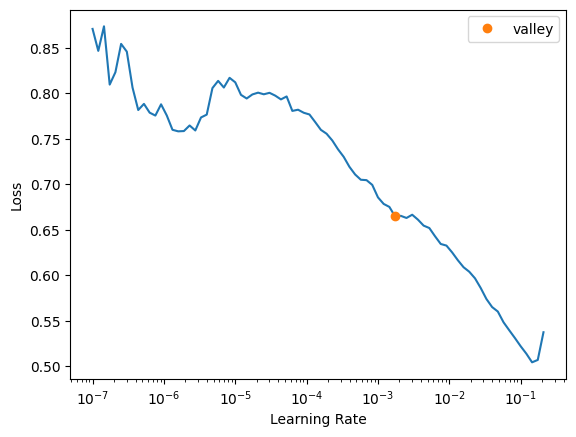

In [ ]:
lr_suggestion = learn.lr_find()

In [ ]:
print("Learning rate sugerido (valley):", lr_suggestion.valley)

Learning rate sugerido (valley): 0.001737800776027143


In [ ]:
lr_value = lr_suggestion.valley

print(f"Learning rate usado para entrenar: {lr_value}")

Learning rate usado para entrenar: 0.001737800776027143




> Resultado del entrenamiento



In [ ]:
learn.fit_one_cycle(25, lr_max=lr_value)

epoch,train_loss,valid_loss,accuracy,time
0,0.784557,0.609536,0.500000,00:00
1,0.659540,0.656672,0.500000,00:00
2,0.582397,0.661920,0.500000,00:00
3,0.578011,0.585999,0.500000,00:00
4,0.535568,0.590757,0.500000,00:00
5,0.515719,0.467672,0.500000,00:00
6,0.483091,0.392951,0.500000,00:00
7,0.443977,0.336702,0.500000,00:00
8,0.398447,0.307540,0.500000,00:00
9,0.357640,0.229894,0.500000,00:00


###05. Evaluación en Test

In [ ]:
df_all = pd.concat([df_train, df_test], ignore_index=True)

In [ ]:
test_valid_idx = list(range(len(df_train), len(df_all)))

In [ ]:
# Dataloader de test
dls_test = TabularDataLoaders.from_df(
    df_all,
    path='.',
    procs=procs,
    cat_names=cat_names,
    cont_names=cont_names,
    y_names=dep_var,
    valid_idx=test_valid_idx,
    bs=32
)

In [ ]:
learn.dls = dls_test

In [ ]:
test_metrics = learn.validate()

In [ ]:
print("Loss en test:", test_metrics[0])
print("Accuracy en test:", test_metrics[1])

Loss en test: 0.12619313597679138
Accuracy en test: 0.5409836173057556


###06. Interpretación

Obtenemos las predicciones sobre el conjunto de validación actual, correspondiente al test.

In [ ]:
preds, targs = learn.get_preds(dl=learn.dls.valid)

In [ ]:
y_pred = preds.argmax(dim=1).numpy()
y_true = targs.numpy()

In [ ]:
# Métricas
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("MÉTRICAS EN TEST:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

MÉTRICAS EN TEST:
Accuracy : 0.5410
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


In [ ]:
print("CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred))

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        33
           1       0.00      0.00      0.00        28

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))




> Matriz de Confusión



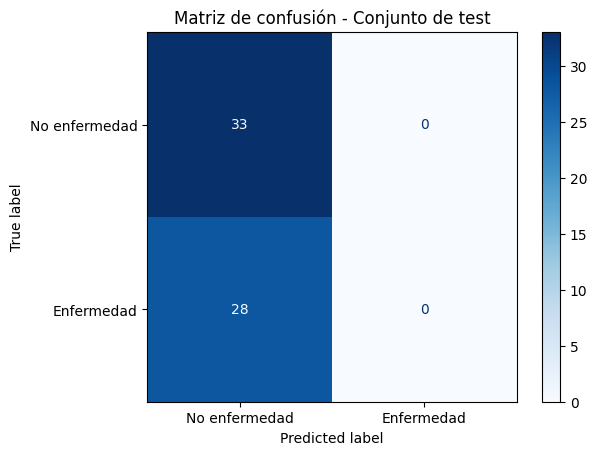

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No enfermedad", "Enfermedad"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Conjunto de test")
plt.show()

###07. Predicción en un ejemplo

In [ ]:
sample_x = df_test.iloc[0].drop(dep_var)

pred_class, pred_idx, pred_probs = learn.predict(sample_x)

print("Clase predicha:", pred_class)
print("Índice predicho:", pred_idx)
print("Probabilidades:", pred_probs)

Clase predicha:    sex   cp  fbs  restecg  exang  slope   ca  thal       age  trestbps  \
0  2.0  4.0  1.0      3.0    1.0    1.0  1.0   1.0  0.495681  0.400391   

       chol   thalach   oldpeak    target  
0  0.401254  1.415099 -0.891627  0.357958  
Índice predicho: tensor([0.3580])
Probabilidades: tensor([0.3580])
